In [90]:
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
import numpy as np
df = pd.read_csv(r"C:\All project\Advanced Multi-Source Data Pipeline\crypto_data_cleaned.csv")
df.head(5)


,id,symbol,name,image,current_price,market_cap,market_cap_rank,fully_diluted_valuation,total_volume,high_24h,...,atl,atl_change_percentage,atl_date,roi,last_updated,IQR_Outlier,Isolation_Forest_Outlier,Market_Cap_Category,Volatility_Score,Supply_Ratio
0,bitcoin,btc,Bitcoin,https://coin-images.coingecko.com/coins/images...,79521.000000,1.596908e+12,1,1596917360999,3.401496e+10,79701.000000,...,67.810000,1.171716e+05,2013-07-05T16:00:00.000Z,NaN,2026-09-09 09:14:20+00:00,True,True,Mega,417.781799,0.999994
1,ethereum,eth,Ethereum,https://coin-images.coingecko.com/coins/images...,2511.780000,3.065182e+11,2,306518201478,1.198981e+10,2521.510000,...,0.432979,5.800154e+05,2015-10-19T16:00:00.000Z,"{'times': 41.23061842109489, 'currency': 'btc'...",2026-09-09 09:14:20+00:00,True,True,Mega,147.262341,1.000000
2,tether,usdt,Tether,https://coin-images.coingecko.com/coins/images...,0.999752,1.834146e+11,3,188880189741,5.250357e+10,0.999995,...,0.572521,7.462283e+01,2015-03-01T16:00:00.000Z,NaN,2026-09-09 09:14:20+00:00,True,True,Mega,644.864303,0.971063
3,binancecoin,bnb,BNB,https://coin-images.coingecko.com/coins/images...,756.770000,1.007744e+11,4,100774365637,9.948938e+08,757.670000,...,0.039818,1.900491e+06,2017-10-18T16:00:00.000Z,NaN,2026-09-09 09:14:20+00:00,True,True,Mega,12.219579,1.000000
4,ripple,xrp,XRP,https://coin-images.coingecko.com/coins/images...,1.430000,8.989540e+10,5,143251551449,2.588803e+09,1.450000,...,0.002686,5.322878e+04,2014-05-21T16:00:00.000Z,NaN,2026-09-09 09:14:20+00:00,True,False,Mega,31.796446,0.627535


#  Univariate Analysis


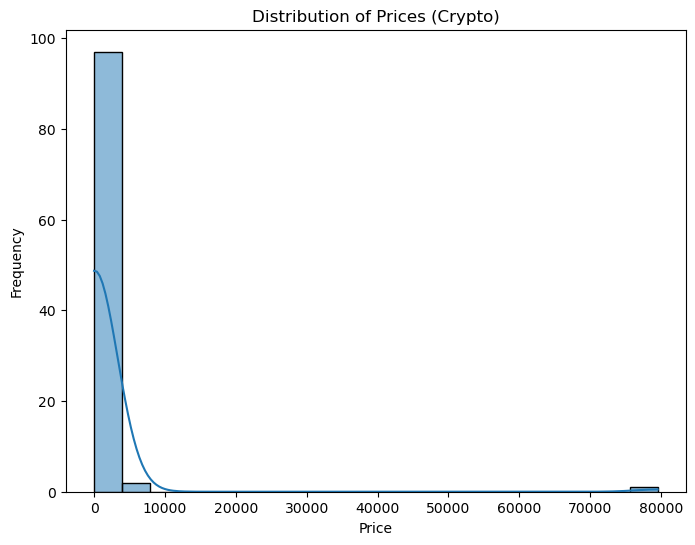

In [91]:
# Distribution of prices, market caps, volumes (Crypto)
# Histogram + KDE + Box plots

plt.figure(figsize=(8, 6))
sns.histplot(df["current_price"], kde=True)
plt.title('Distribution of Prices (Crypto)');plt.xlabel('Price');plt.ylabel('Frequency');plt.show()



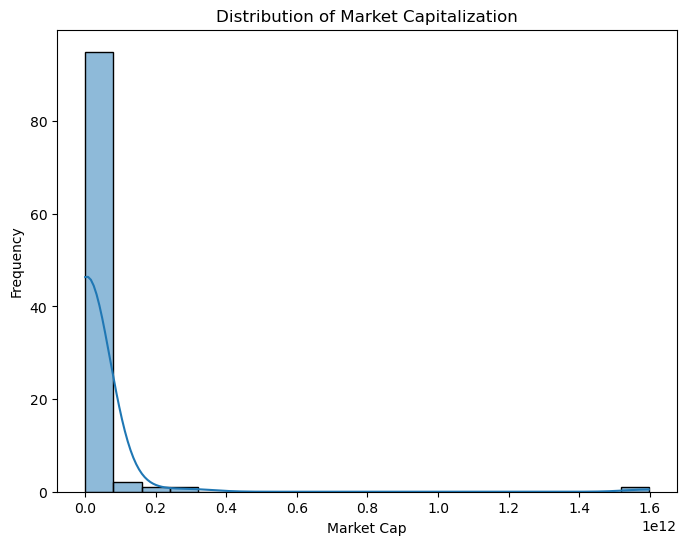

In [92]:
# market cap distribution
plt.figure(figsize=(8, 6))

sns.histplot(df["market_cap"], kde=True)
plt.title('Distribution of Market Capitalization')
plt.xlabel('Market Cap')
plt.ylabel('Frequency')
plt.show()

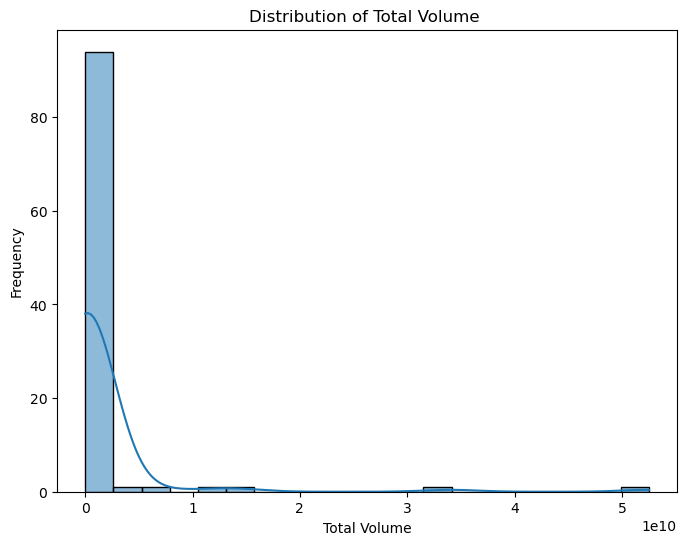

In [93]:
# Volumes (Crypto) Distribution

plt.figure(figsize=(8, 6))

sns.histplot(df["total_volume"], kde=True)
plt.title('Distribution of Total Volume ');plt.xlabel('Total Volume');plt.ylabel('Frequency');plt.show()

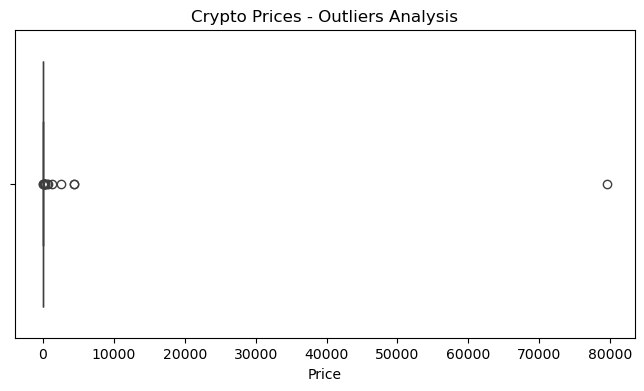

In [94]:
# Box Plot for Prices
plt.figure(figsize=(8, 4))

sns.boxplot(x=df["current_price"])
plt.title('Crypto Prices - Outliers Analysis');plt.xlabel('Price');plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

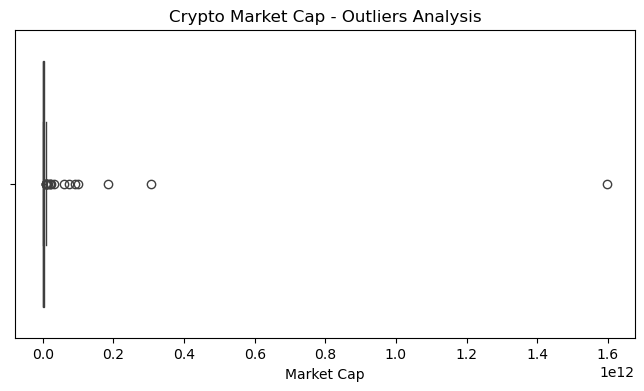

In [95]:
# Box Plot for Market Cap
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["market_cap"])
plt.title('Crypto Market Cap - Outliers Analysis');plt.xlabel('Market Cap');plt.show

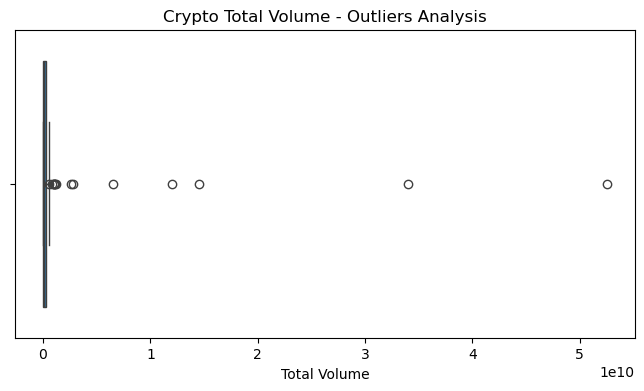

In [96]:
# Box Plot for Volumes (Crypto)

plt.figure(figsize=(8, 4))
sns.boxplot(x=df["total_volume"])
plt.title('Crypto Total Volume - Outliers Analysis');plt.xlabel('Total Volume');plt.show()

#  Bivariate Analysis

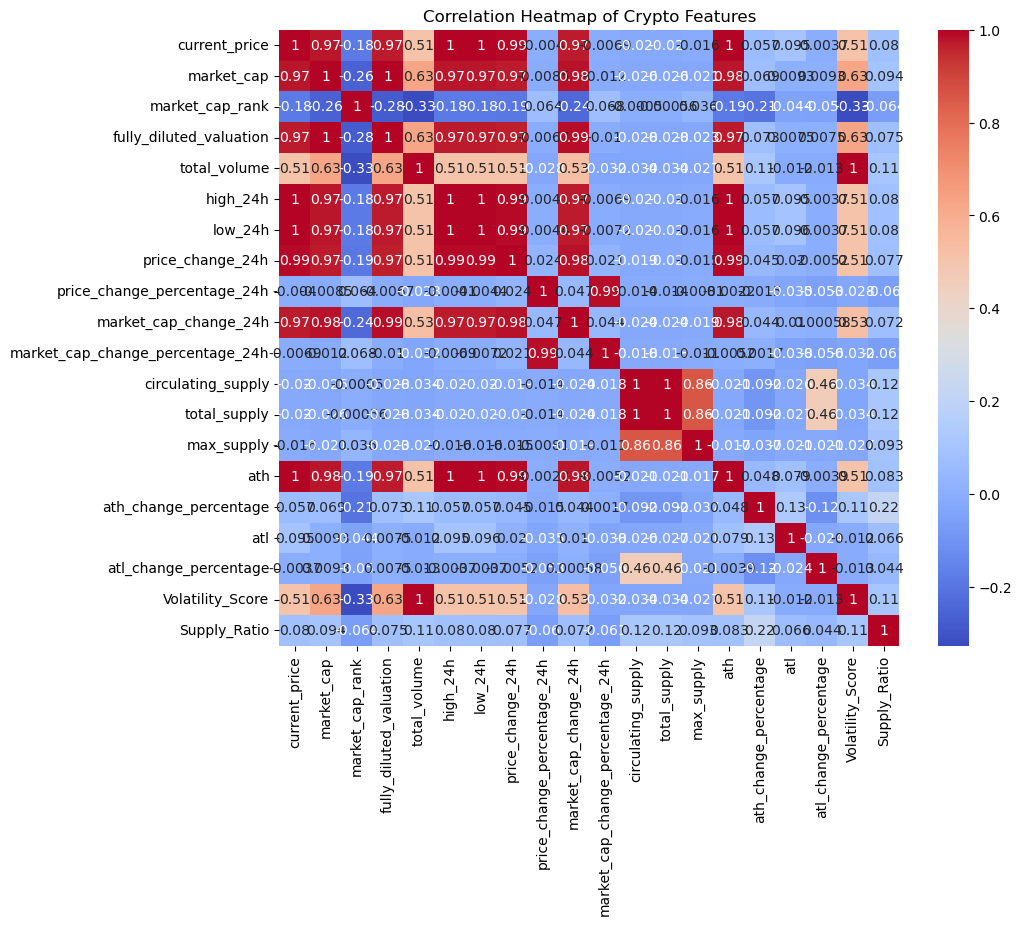

In [98]:
# Correlation heatmap (numerical features)



plt.figure(figsize=(10, 8))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Crypto Features')
plt.show()

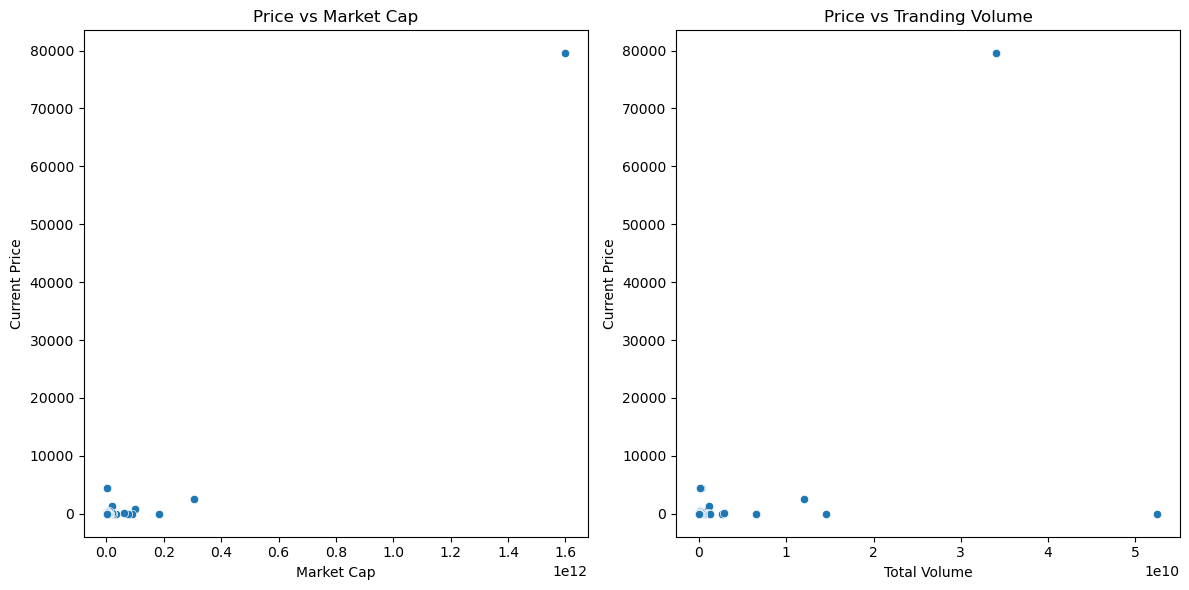

In [101]:
# Current Price vs Market Cap  and Current Price vs Total Volume

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x='market_cap', y='current_price', data=df)
plt.title('Price vs Market Cap')
plt.xlabel('Market Cap')
plt.ylabel('Current Price')

plt.subplot(1, 2, 2)
sns.scatterplot(x='total_volume', y='current_price', data=df)
plt.title('Price vs Tranding Volume')
plt.xlabel('Total Volume')
plt.ylabel('Current Price')

plt.tight_layout()
plt.show()



#  Multivariate Analysis

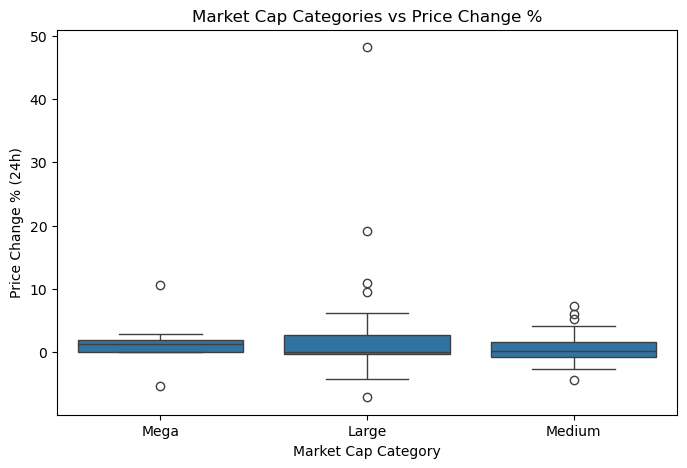

In [102]:



# Market Cap categories vs Price Change %
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Market_Cap_Category',
    y='price_change_percentage_24h'
    )
plt.title('Market Cap Categories vs Price Change %');plt.xlabel('Market Cap Category');plt.ylabel('Price Change % (24h)');plt.show()

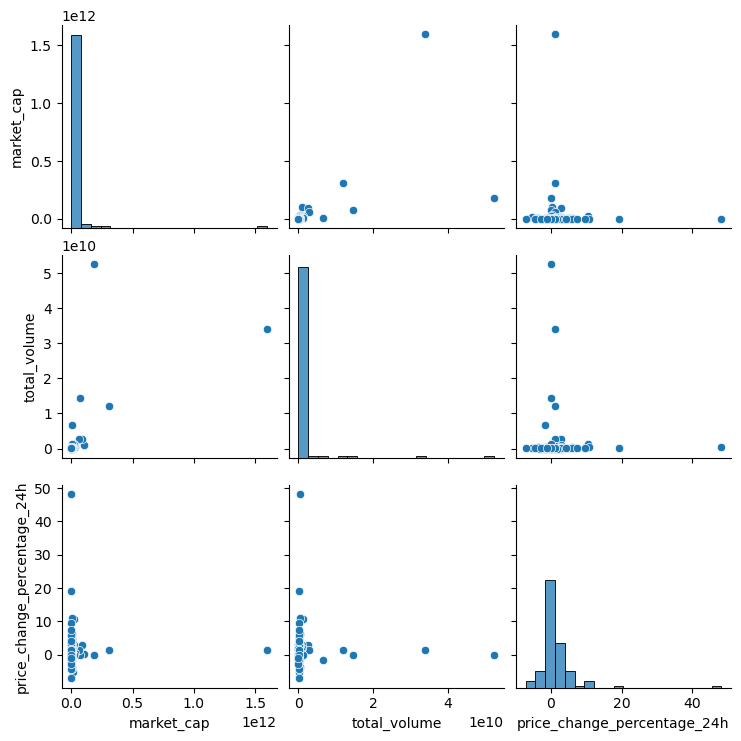

In [103]:
# Pair plots


sns.pairplot(
    df[['market_cap', 'total_volume', 'price_change_percentage_24h']]
)
plt.show()

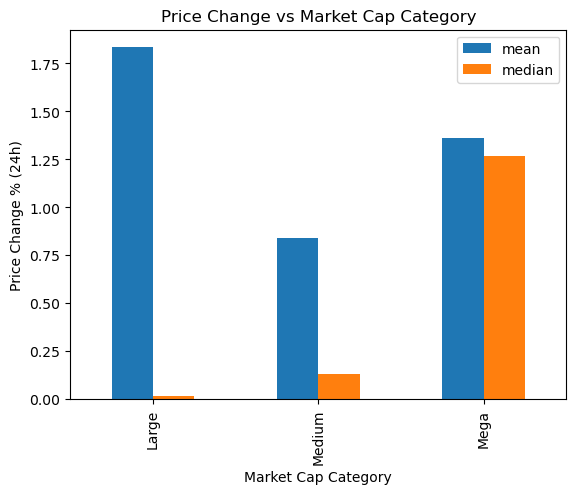

In [104]:
# Grouped aggregations (mean, median by category)

df.groupby('Market_Cap_Category')["price_change_percentage_24h"].agg(
    ['mean', 'median']
).plot(kind='bar')

plt.title('Price Change vs Market Cap Category');plt.xlabel('Market Cap Category');plt.ylabel('Price Change % (24h)');plt.show()

#  Advanced EDA

Number of outliers in Market Cap: 17
--------------------------------------------------


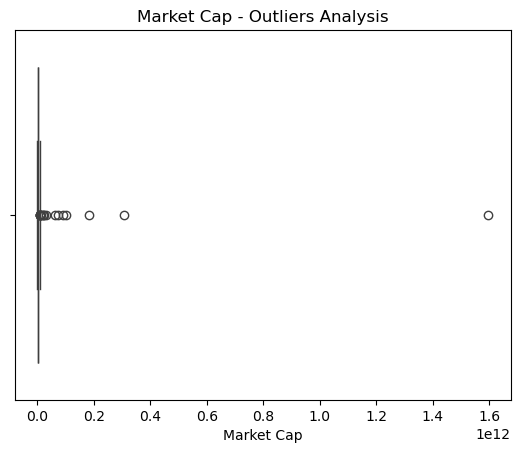

In [106]:
# Outlier analysis and impact

Q1 = df["market_cap"].quantile(0.25)
Q3 = df["market_cap"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df["market_cap"] < lower_bound) | (df["market_cap"] > upper_bound)]
print(f"Number of outliers in Market Cap: {len(outliers)}")
print("-"*50)
sns.boxplot(x=df["market_cap"])
plt.title('Market Cap - Outliers Analysis');plt.xlabel('Market Cap');plt.show()

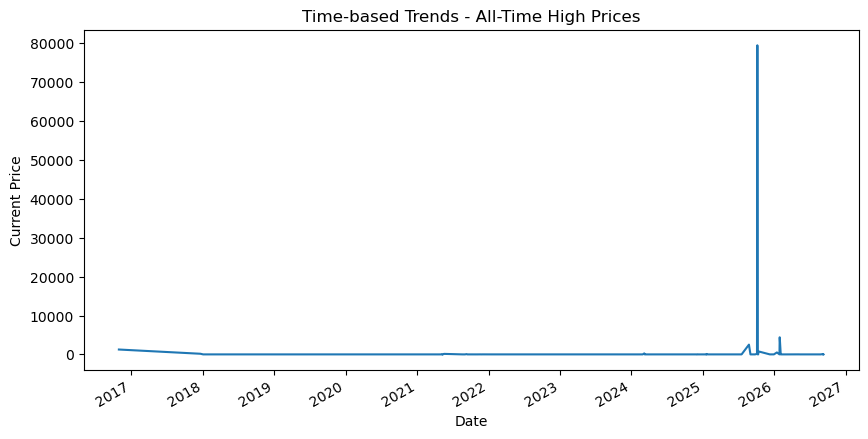

In [110]:
# Time-based trends (if using historical data)

df["ath_date"] = pd.to_datetime(df["ath_date"])

df.groupby("ath_date")["current_price"].mean().plot(kind='line', figsize=(10, 5))
plt.title('Time-based Trends - All-Time High Prices');plt.xlabel('Date');plt.ylabel('Current Price');plt.show()



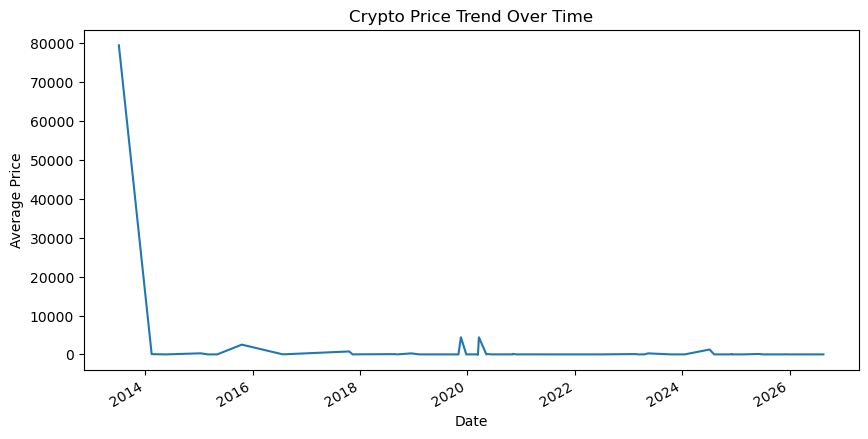

In [111]:
# Crypto Price Trend Over Time by grooup
df["atl_date"] = pd.to_datetime(df["atl_date"])

df.groupby("atl_date")["current_price"].mean().plot(kind='line', figsize=(10, 5))

plt.title("Crypto Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Average Price")
plt.show()


#  Insights Generation

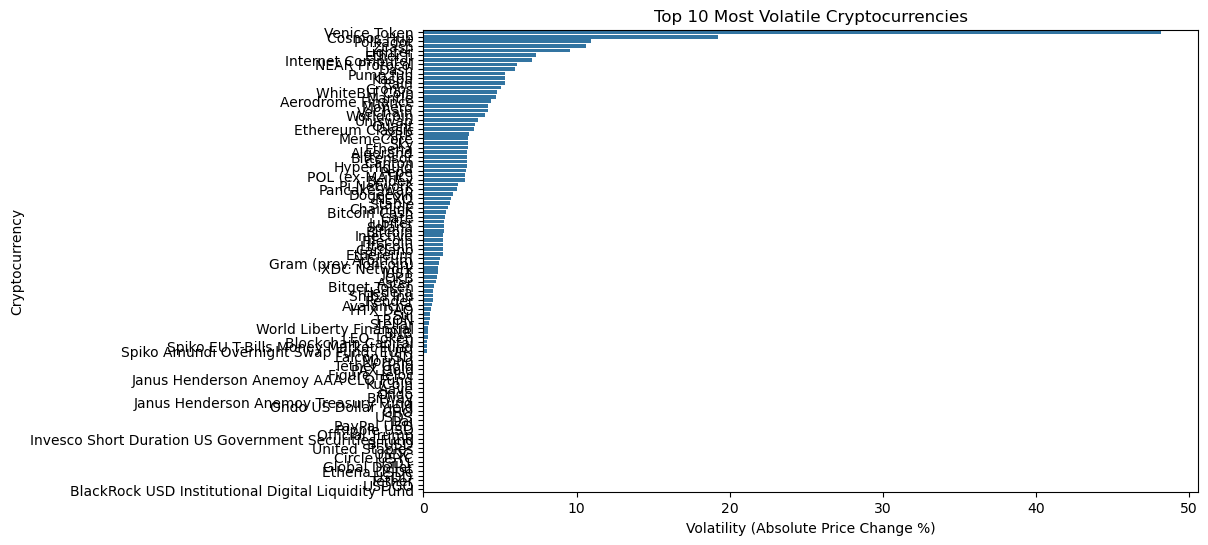

In [113]:
# Top 10 Most Volatile Cryptocurrencies

plt.figure(figsize=(10, 6))
df["Volatility"] = df["price_change_percentage_24h"].abs()

high_volatility = df.sort_values(
    "Volatility", ascending=False
)[["name", "price_change_percentage_24h", "Volatility"]]


sns.barplot(
    x="Volatility",
    y="name",
    data=high_volatility
)

plt.title("Top 10 Most Volatile Cryptocurrencies")
plt.xlabel("Volatility (Absolute Price Change %)")
plt.ylabel("Cryptocurrency")
plt.show()

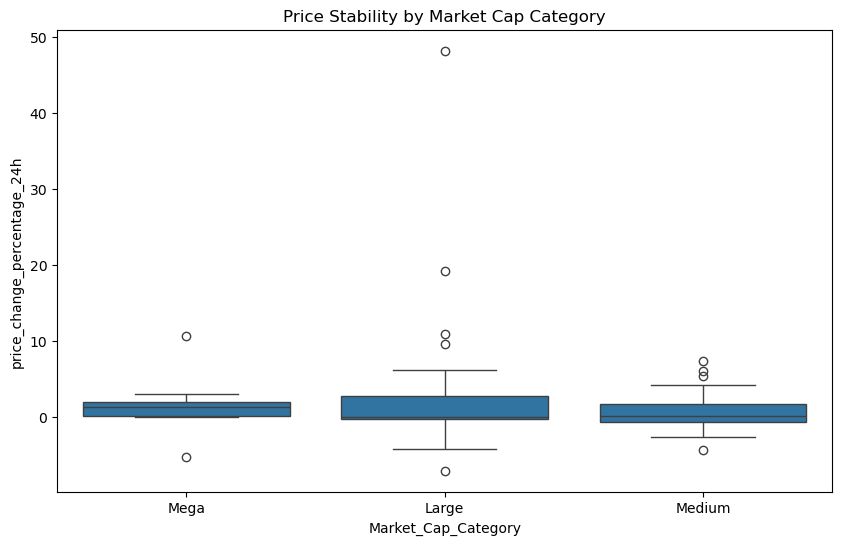

In [114]:
# Price Stability by Market Cap Category
plt.figure(figsize=(10, 6))
sns.boxplot(
    x="Market_Cap_Category",
    y="price_change_percentage_24h",
    data=df
)

plt.title("Price Stability by Market Cap Category")
plt.show()


In [115]:
df.to_csv("Visualized_Crypto_data.csv", index = False)